### Finite Difference Methods

**Finite Difference Methods** approximate the derivative of a function using nearby function values, without requiring symbolic differentiation.

$$
\text{Forward:}\quad f'(x) \approx \frac{f(x+h)-f(x)}{h}
$$
$$
\text{Backward:}\quad f'(x) \approx \frac{f(x)-f(x-h)}{h}
$$
$$
\text{Central:}\quad f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}
$$

The **central difference** formula is generally the most accurate, with error \\(O(h^2)\\), compared to \\(O(h)\\) for forward and backward differences.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return np.sin(x)

def df_exact(x):
    return np.cos(x)


In [3]:
def finite_difference_table(f, x, h_values):
    print(f"{'h':>10} {'forward':>12} {'backward':>12} {'central':>12} {'exact':>12} {'central err':>14}")
    print("-" * 75)

    for h in h_values:
        forward = (f(x + h) - f(x)) / h
        backward = (f(x) - f(x - h)) / h
        central = (f(x + h) - f(x - h)) / (2 * h)
        exact = df_exact(x)
        error = abs(central - exact)

        print(f"{h:10.6f} {forward:12.6f} {backward:12.6f} {central:12.6f} {exact:12.6f} {error:14.6e}")

    return central


In [4]:
x0 = 1.0
h_values = [0.5, 0.1, 0.01, 0.001]
central = finite_difference_table(f, x0, h_values)
print(f"\nBest central-difference estimate of f'({x0}) = {central:.6f}")
print(f"Exact derivative f'({x0}) = {df_exact(x0):.6f}")


         h      forward     backward      central        exact    central err
---------------------------------------------------------------------------
  0.500000     0.312048     0.724091     0.518069     0.540302   2.223286e-02
  0.100000     0.497364     0.581441     0.539402     0.540302   9.000537e-04
  0.010000     0.536086     0.544501     0.540293     0.540302   9.004993e-06
  0.001000     0.539881     0.540723     0.540302     0.540302   9.005045e-08

Best central-difference estimate of f'(1.0) = 0.540302
Exact derivative f'(1.0) = 0.540302


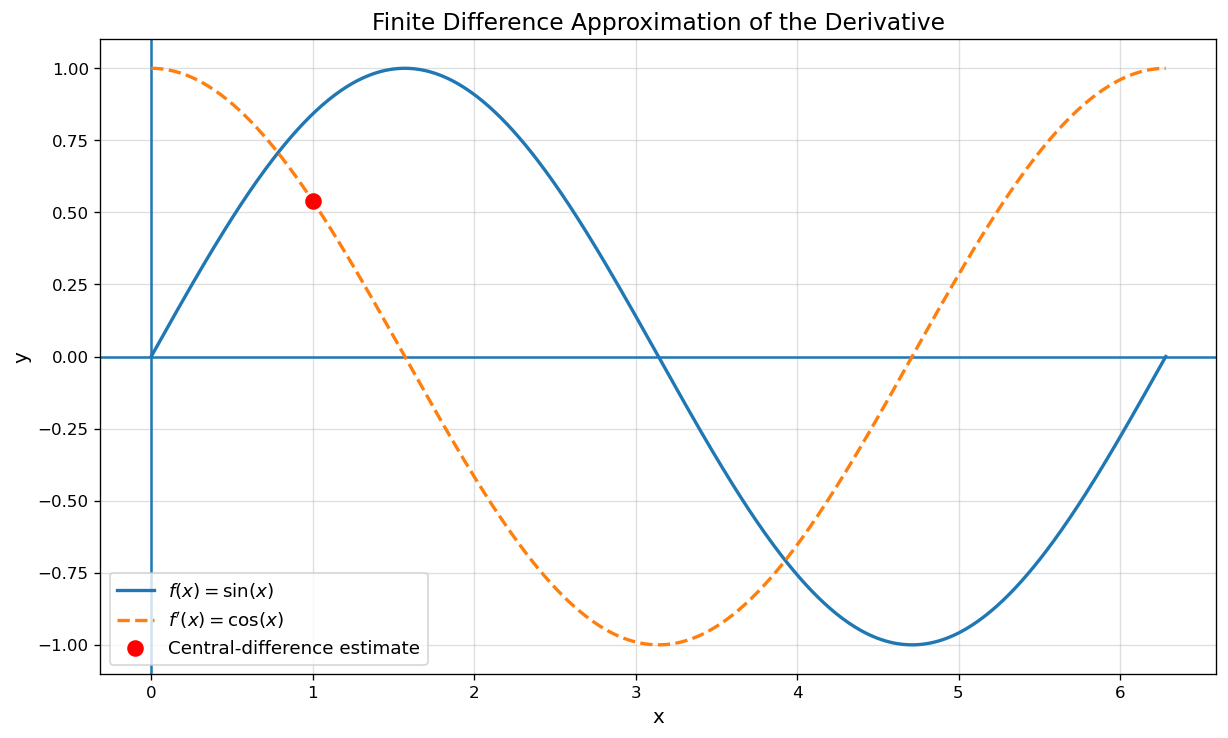

In [5]:
plt.figure(figsize=(12, 7), dpi=120)

# Axes lines (Desmos-style)
plt.axhline(0)
plt.axvline(0)

x = np.linspace(0, 2 * np.pi, 500)
y = f(x)
dy = df_exact(x)

plt.plot(x, y, linewidth=2, label=r"$f(x)=\sin(x)$")
plt.plot(x, dy, linewidth=2, linestyle="--", label=r"$f'(x)=\cos(x)$")
plt.scatter([x0], [central], s=80, zorder=5, color="red", label="Central-difference estimate")

plt.grid(True, alpha=0.4)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Finite Difference Approximation of the Derivative", fontsize=14)

plt.legend(fontsize=11)
plt.show()
